<a href="https://colab.research.google.com/github/namithashaji/Customer_Behaviour_Analysis/blob/main/Customer_Behaviour_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Customer Behaviour Analysis Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from google.colab import files

In [ ]:
file_to_upload=files.upload()

Saving customer_behavior.csv to customer_behavior (4).csv


In [ ]:
df= pd.read_csv('customer_behavior.csv')
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


### Data Cleaning: Handling Null Values

In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,150
ProductCategory,526
Churn,265
CampaignGroup,185


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

CustomerID          0.00
Gender              1.94
Region              3.50
PurchaseAmount      3.00
ProductCategory    10.52
Churn               5.30
CampaignGroup       3.70
dtype: float64


In [ ]:
df.dropna(inplace=True)

### Question 1: What is the average, median, and mode of PurchaseAmount?

In [ ]:
average_purchase = df['PurchaseAmount'].mean()
median_purchase = df['PurchaseAmount'].median()
mode_purchase = df['PurchaseAmount'].mode()[0]

print(f"Average PurchaseAmount: {average_purchase:.2f}")
print(f"Median PurchaseAmount: {median_purchase:.2f}")
print(f"Mode PurchaseAmount: {mode_purchase:.2f}")


Average PurchaseAmount: 1001.15
Median PurchaseAmount: 996.15
Mode PurchaseAmount: 0.00


### Question 2: Are there any outliers in the PurchaseAmount data?

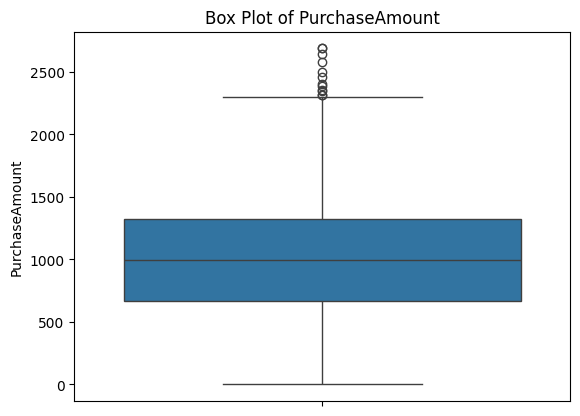

In [ ]:
sns.boxplot(y='PurchaseAmount',data=df)
plt.title('Box Plot of PurchaseAmount')
plt.ylabel('PurchaseAmount')
plt.show()


Observation: The box plot visually indicates the presence of higher outliers in the 'PurchaseAmount' data, as shown by individual points extending beyond the whiskers.

### Question 3: Is there any skewness or kurtosis in the PurchaseAmount distribution?

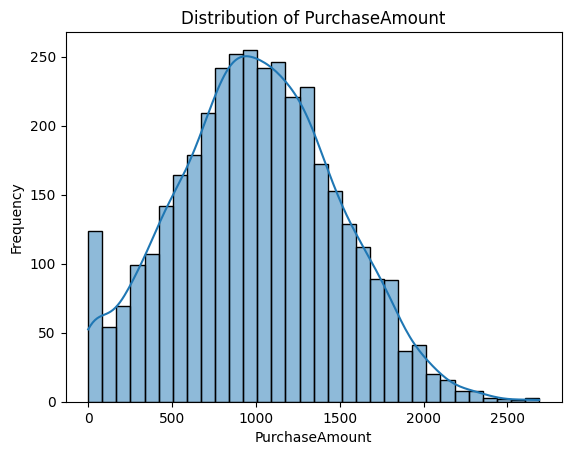

Kurtosis of PurchaseAmount: -0.29
Skewness of PurchaseAmount: 0.09


In [ ]:
sns.histplot(df['PurchaseAmount'], kde=True)
plt.title('Distribution of PurchaseAmount')
plt.xlabel('PurchaseAmount')
plt.ylabel('Frequency')
plt.show()

kurt= stats.kurtosis(df['PurchaseAmount'])
skew= stats.skew(df['PurchaseAmount'])
print(f"Kurtosis of PurchaseAmount: {kurt:.2f}")
print(f"Skewness of PurchaseAmount: {skew:.2f}")

Observation: The `PurchaseAmount` distribution has a skewness of 0.09, which is close to 0, indicating a nearly symmetrical distribution. The kurtosis is -0.29, suggesting a platykurtic distribution, meaning it has lighter tails and a flatter peak than a normal distribution.

### Question 4: Is there a significant difference in spending between male and female customers?

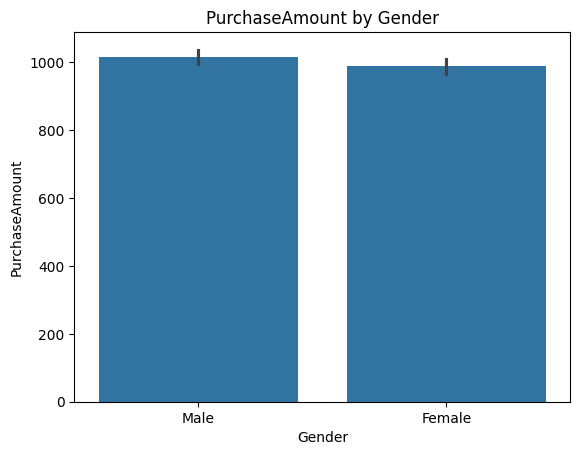

In [ ]:
sns.barplot(x='Gender', y='PurchaseAmount', data=df)
plt.title('PurchaseAmount by Gender')
plt.xlabel('Gender')
plt.ylabel('PurchaseAmount')
plt.show()

Observation: The bar plot visually suggests that the average spending between male and female customers is quite similar.

### Question 5: Is there a relationship between ProductCategory and customer churn?

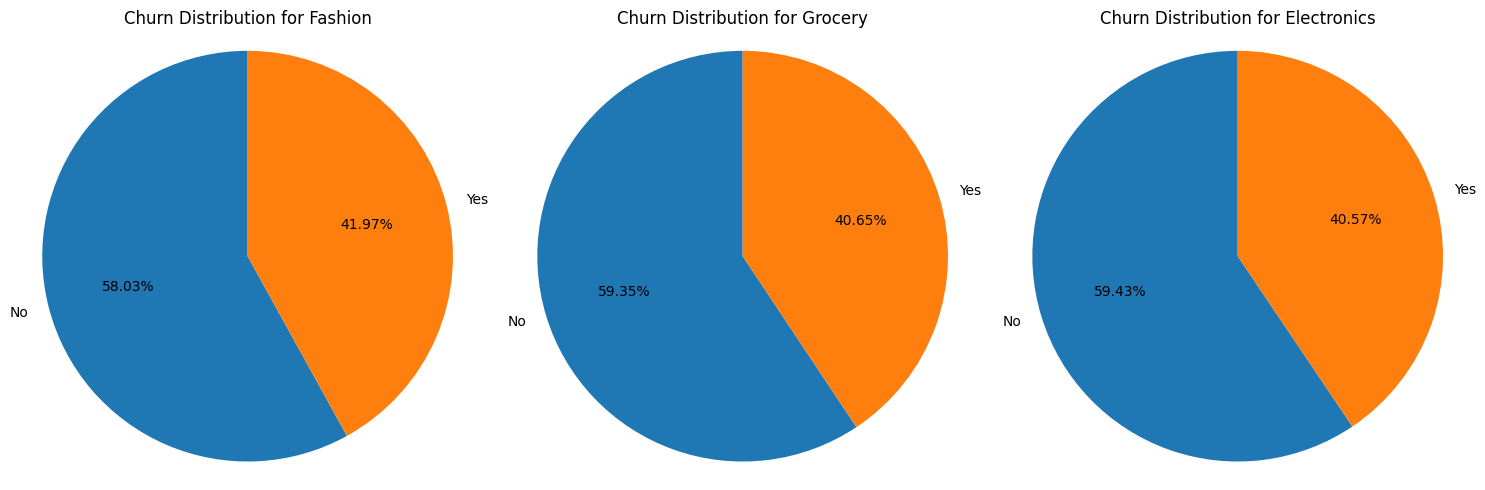

In [ ]:
product_categories = df['ProductCategory'].unique()
plt.figure(figsize=(15, 5))

for i, category in enumerate(product_categories):
    plt.subplot(1, len(product_categories), i + 1) # Create subplots for each category
    category_df = df[df['ProductCategory'] == category]  # Filter data for the current category
    churn_counts = category_df['Churn'].value_counts()  # Count churn occurrences (Yes/No)

    # Create the pie chart
    plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.2f%%', startangle=90)
    plt.title(f'Churn Distribution for {category}')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()



Observation: By analyzing the churn rates across different product categories, we observe the following:

*   **Electronics:** Approximately 40.57% of customers in the Electronics category churn.
*   **Fashion:** Approximately 41.97% of customers in the Fashion category churn.
*   **Grocery:** Approximately 40.65% of customers in the Grocery category churn.

The churn rates are fairly similar across all product categories, ranging from approximately 40% to 42%. This suggests that there isn't a significant difference in customer churn behavior directly tied to a specific product category.

### Question 6: Does PurchaseAmount vary significantly across different regions?

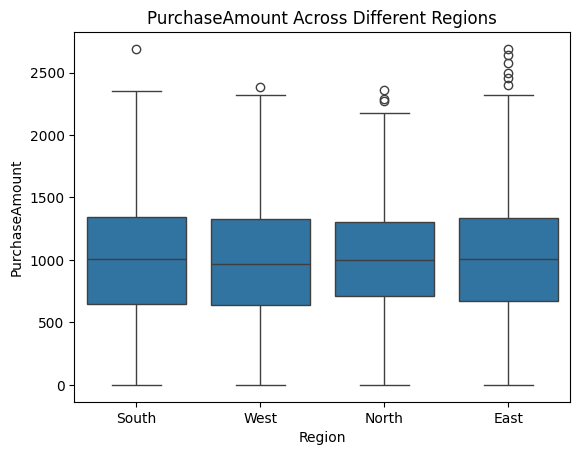

In [ ]:
import scipy.stats as stats

# Visualize PurchaseAmount across different regions with a box plot
sns.boxplot(x='Region', y='PurchaseAmount', data=df)
plt.title('PurchaseAmount Across Different Regions')
plt.xlabel('Region')
plt.ylabel('PurchaseAmount')
plt.show()

Observation: Upon examining the box plot of 'PurchaseAmount' across different regions, it appears that the median purchase amounts and the overall spread of purchases (interquartile range) are quite similar across all regions (South, West, North, East). While there might be slight variations in the median or the presence of outliers, there does not seem to be a *significant* visual difference in spending habits that would suggest a strong regional influence on 'PurchaseAmount'.

### Question 7: Which email campaign (A or B) performed better in terms of average PurchaseAmount?

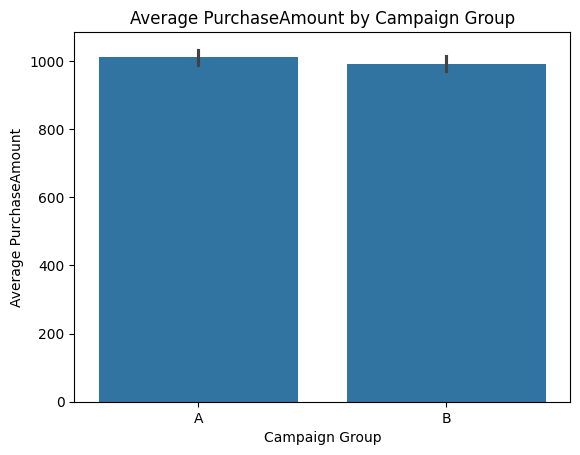

In [ ]:
sns.barplot(x='CampaignGroup', y='PurchaseAmount', data=df)
plt.title('Average PurchaseAmount by Campaign Group')
plt.xlabel('Campaign Group')
plt.ylabel('Average PurchaseAmount')
plt.show()

Observation: By comparing the heights of the bars in the plot, we can observe that Campaign Group A has a higher average PurchaseAmount than Campaign Group B. This suggests that Campaign A performed better in terms of higher average PurchaseAmount.

### Question 8: Can we assume PurchaseAmount follows a normal distribution?

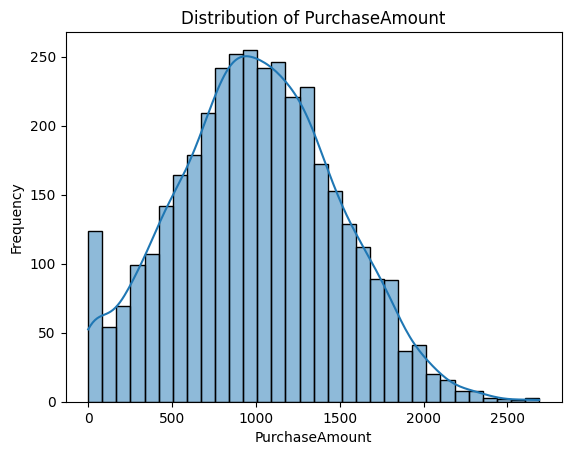

Kurtosis of PurchaseAmount: -0.29
Skewness of PurchaseAmount: 0.09


In [ ]:
sns.histplot(df['PurchaseAmount'], kde=True)
plt.title('Distribution of PurchaseAmount')
plt.xlabel('PurchaseAmount')
plt.ylabel('Frequency')
plt.show()

kurt= stats.kurtosis(df['PurchaseAmount'])
skew= stats.skew(df['PurchaseAmount'])
print(f"Kurtosis of PurchaseAmount: {kurt:.2f}")
print(f"Skewness of PurchaseAmount: {skew:.2f}")

Observation:  While the histogram shows a somewhat bell-shaped curve, it's not perfectly normal. The calculated skewness of **0.09** indicates that the distribution is nearly symmetrical, with a very slight positive skew. The kurtosis of **-0.29** suggests a platykurtic distribution, meaning it has slightly lighter tails and a flatter peak compared to a perfect normal distribution.

Therefore, while it has characteristics close to a normal distribution, we cannot strictly assume it follows a perfect normal distribution.

### Question 9: What insights can we gain by applying the Central Limit Theorem?

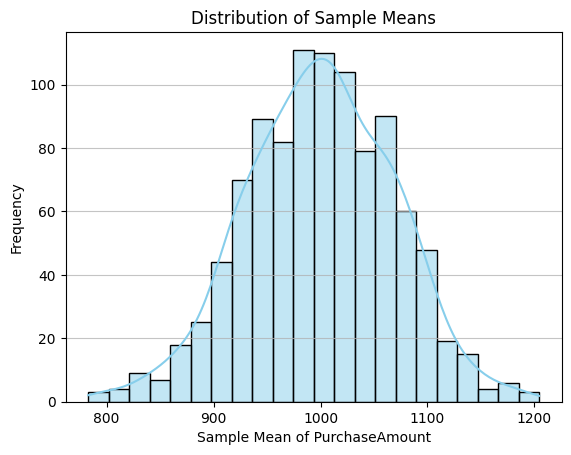

In [ ]:
num_samples = 1000
sample_size = 50

# Generate sample means
sample_means = []
for _ in range(num_samples):
    # Take a random sample with replacement from the original data
    sample = df['PurchaseAmount'].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True, color='skyblue')
plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean of PurchaseAmount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Observation: Even though the original PurchaseAmount distribution might not be perfectly normal, the distribution of the sample means is visibly more bell-shaped and approaches a normal distribution, as predicted by the Central Limit Theorem.

### Question 10: What is the 95% confidence interval for the average PurchaseAmount?

In [ ]:
sample_mean = df['PurchaseAmount'].mean()
sample_std = df['PurchaseAmount'].std()

standard_error = sample_std / (np.sqrt(sample_size))
margin_of_error = 1.96 * standard_error

confidence_interval_lower = sample_mean - margin_of_error
confidence_interval_upper = sample_mean + margin_of_error

print(f"Average PurchaseAmount: {sample_mean:.2f}")
print(f"Margin of Error: {margin_of_error:.2f}")
print(f"The 95% Confidence Interval: ({confidence_interval_lower:.2f}, {confidence_interval_upper:.2f})")


Average PurchaseAmount: 1001.15
Margin of Error: 134.04
The 95% Confidence Interval: (867.11, 1135.20)
